# Crop Pest SVM Classifier
13-type feature fusion (2836 dims): HSV Histogram, Hu Moments, LBP, HOG, Contour Geometry, GLCM Haralick, Color Moments, Multi-scale LBP, Gabor, Zernike, Fourier, Canny, Color Correlogram

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import os
import logging
import pickle
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

logging.basicConfig(level=logging.WARNING, format='[%(name)s] %(levelname)s: %(message)s')

from shared import (
    resolve_paths, yolo_box_to_xyxy, clamp_xyxy,
    plot_confusion_matrix, save_classification_report,
)
from feature_extraction import extract_features, create_hog_descriptor, FEATURE_DIM, EXTRACTED_DIMS

PROJECT_ROOT, DATA_ROOT, OUT_ROOT = resolve_paths()

FEATURE_CACHE_DIR = Path(OUT_ROOT) / "svm_cache"
FEATURE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT: f:\github\agro-pest
DATA_ROOT:    f:\github\agro-pest\archive
OUT_ROOT:     f:\github\agro-pest\runs
Data exists:  True


In [2]:
CONFIG = {
    "YOLO_ROOT": DATA_ROOT,
    "OUT_ROOT": OUT_ROOT,

    "CLASS_NAMES": [
        "Ants", "Bees", "Beetles", "Caterpillars", "Earthworms", "Earwigs",
        "Grasshoppers", "Moths", "Slugs", "Snails", "Wasps", "Weevils",
    ],

    "CROP_MARGIN_RATIO": 0.05,
    "MIN_CROP_SIZE": 20,
    "RESIZE_TO": (64, 64),

    "SVM_KERNEL": "rbf",
    "SVM_C": 10,
    "SVM_GAMMA": "scale",
    "SVM_CACHE_SIZE": 2000,
}

cfg = CONFIG

In [3]:
def load_paths(folder):
    images_folder = os.path.join(folder, "images")
    labels_folder = os.path.join(folder, "labels")
    img_exts = {'.jpg', '.jpeg', '.png', '.bmp'}
    image_paths = sorted(
        [os.path.join(images_folder, f) for f in os.listdir(images_folder)
         if os.path.splitext(f)[1].lower() in img_exts]
    )
    label_paths = []
    valid_image_paths = []
    for img_path in image_paths:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        lbl = os.path.join(labels_folder, stem + ".txt")
        if os.path.exists(lbl):
            valid_image_paths.append(img_path)
            label_paths.append(lbl)
    return valid_image_paths, label_paths


def extract_dataset_features(image_paths, label_paths, hog_desc, margin_ratio=0.05, min_crop=20, resize_to=(64, 64), desc="Extracting"):
    X = []
    y = []
    dim_mismatch = 0
    for img_path, label_path in tqdm(zip(image_paths, label_paths), total=len(image_paths), desc=desc):
        img = cv2.imread(img_path)
        if img is None:
            continue
        H, W = img.shape[:2]
        with open(label_path, "r") as f:
            lines = [ln for ln in f.read().strip().splitlines() if ln.strip()]
        for line in lines:
            cid, xyxy = yolo_box_to_xyxy(line, W, H)
            if cid is None or xyxy is None:
                continue
            xyxy = clamp_xyxy(xyxy, W, H, margin_ratio=margin_ratio)
            if xyxy is None:
                continue
            x1, y1, x2, y2 = xyxy
            roi = img[y1:y2, x1:x2]
            if roi.size == 0 or roi.shape[0] < min_crop or roi.shape[1] < min_crop:
                continue
            roi = cv2.resize(roi, resize_to)
            feature = extract_features(roi, hog_desc)
            if feature.shape[0] != FEATURE_DIM:
                dim_mismatch += 1
                continue
            X.append(feature)
            y.append(cid)
        del img
    if dim_mismatch > 0:
        print(f"WARNING: {dim_mismatch} samples skipped due to dimension mismatch (expected {FEATURE_DIM})")
    return np.array(X), np.array(y)


def save_features(cache_path, X, y):
    data = {"X": X, "y": y, "dim": X.shape[1]}
    with open(cache_path, "wb") as f:
        pickle.dump(data, f)
    print(f"Features saved to {cache_path}")


def load_features(cache_path):
    with open(cache_path, "rb") as f:
        data = pickle.load(f)
    cached_dim = data.get("dim", None)
    if cached_dim is not None and cached_dim != FEATURE_DIM:
        print(f"Cache dimension mismatch: cached={cached_dim}, current={FEATURE_DIM}. Invalidating cache.")
        return None, None
    print(f"Features loaded from {cache_path}")
    return data.get("X"), data.get("y")

In [4]:
USE_CACHE = True
cache_file = FEATURE_CACHE_DIR / "train_features.pkl"

X_train = None
if USE_CACHE and cache_file.exists():
    X_train, y_train = load_features(cache_file)

if X_train is None:
    train_folder = os.path.join(cfg["YOLO_ROOT"], "train")
    train_image_paths, train_label_paths = load_paths(train_folder)
    hog_desc = create_hog_descriptor()
    X_train, y_train = extract_dataset_features(
        train_image_paths, train_label_paths, hog_desc,
        margin_ratio=cfg["CROP_MARGIN_RATIO"],
        min_crop=cfg["MIN_CROP_SIZE"],
        resize_to=cfg["RESIZE_TO"],
        desc="Train",
    )
    save_features(cache_file, X_train, y_train)
else:
    hog_desc = create_hog_descriptor()

print(f"Training samples: {len(X_train)}, Feature dim: {X_train.shape[1]}")

unique, counts = np.unique(y_train, return_counts=True)
print("Class distribution:", dict(zip(unique, counts)))

Train: 100%|██████████| 11502/11502 [05:44<00:00, 33.35it/s]


Features saved to f:\github\agro-pest\runs\svm_cache\train_features.pkl
Training samples: 15255, Feature dim: 2836
Class distribution: {0: 2221, 1: 1592, 2: 1058, 3: 1733, 4: 1083, 5: 1182, 6: 1071, 7: 1062, 8: 918, 9: 1196, 10: 1167, 11: 972}


In [5]:
model_cache_file = FEATURE_CACHE_DIR / "svm_model.pkl"

if USE_CACHE and model_cache_file.exists():
    model = joblib.load(model_cache_file)
    print(f"Model loaded from {model_cache_file}")
else:
    model = make_pipeline(
        StandardScaler(),
        SVC(
            kernel=cfg["SVM_KERNEL"],
            C=cfg["SVM_C"],
            gamma=cfg["SVM_GAMMA"],
            cache_size=cfg["SVM_CACHE_SIZE"],
            class_weight="balanced",
            verbose=True,
        ),
    )
    model.fit(X_train, y_train)
    print("SVM training complete")

    joblib.dump(model, model_cache_file)
    print(f"Model saved to {model_cache_file}")

[LibSVM]SVM training complete
Model saved to f:\github\agro-pest\runs\svm_cache\svm_model.pkl


Test: 100%|██████████| 546/546 [00:17<00:00, 30.88it/s]


Features saved to f:\github\agro-pest\runs\svm_cache\test_features.pkl
Test samples: 689
Test accuracy: 0.5602
              precision    recall  f1-score   support

        Ants     0.5806    0.6207    0.6000        87
        Bees     0.5538    0.8182    0.6606        44
     Beetles     0.3250    0.2955    0.3095        44
Caterpillars     0.4853    0.7097    0.5764        93
  Earthworms     0.4878    0.5000    0.4938        40
     Earwigs     0.4783    0.3014    0.3697        73
Grasshoppers     0.4545    0.4545    0.4545        55
       Moths     0.7907    0.7234    0.7556        47
       Slugs     0.6071    0.3333    0.4304        51
      Snails     0.7660    0.7200    0.7423        50
       Wasps     0.5918    0.6170    0.6042        47
     Weevils     0.7391    0.5862    0.6538        58

    accuracy                         0.5602       689
   macro avg     0.5717    0.5567    0.5542       689
weighted avg     0.5673    0.5602    0.5532       689



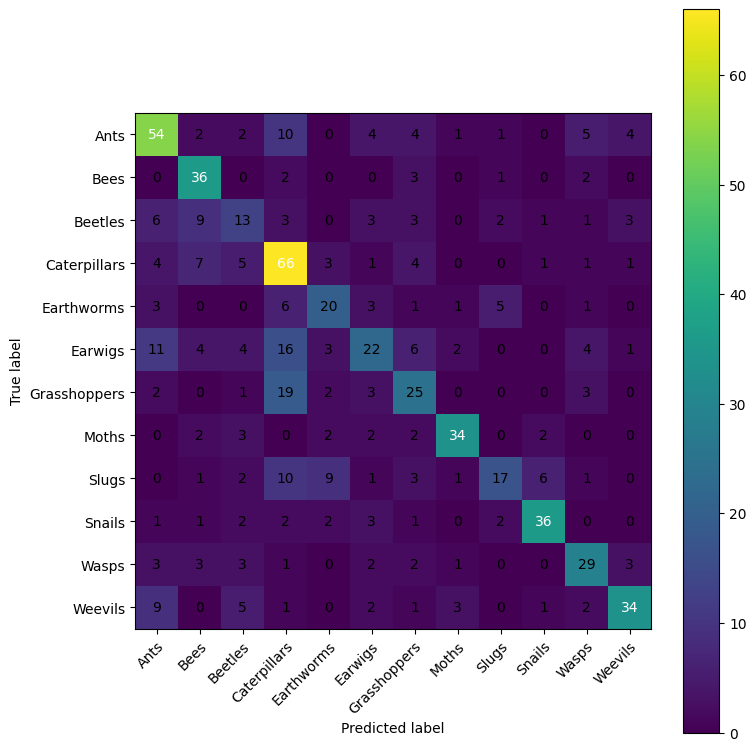


=== DONE (SVM) ===


In [6]:
USE_CACHE = True
cache_file_test = FEATURE_CACHE_DIR / "test_features.pkl"

X_test = None
if USE_CACHE and cache_file_test.exists():
    X_test, y_test = load_features(cache_file_test)

if X_test is None:
    test_folder = os.path.join(cfg["YOLO_ROOT"], "test")
    test_image_paths, test_label_paths = load_paths(test_folder)
    X_test, y_test = extract_dataset_features(
        test_image_paths, test_label_paths, hog_desc,
        margin_ratio=cfg["CROP_MARGIN_RATIO"],
        min_crop=cfg["MIN_CROP_SIZE"],
        resize_to=cfg["RESIZE_TO"],
        desc="Test",
    )
    save_features(cache_file_test, X_test, y_test)

print(f"Test samples: {len(X_test)}")

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=cfg["CLASS_NAMES"], digits=4))

cm = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, cfg["CLASS_NAMES"], os.path.join(cfg["OUT_ROOT"], "svm_cm_test.png"))

save_classification_report(
    Path(cfg["OUT_ROOT"]), y_test, y_pred, cfg["CLASS_NAMES"]
)

print("\n=== DONE (SVM) ===")